(example_neurocombat_in_mareos)=

# Notebook Explanation

## 1) Setup and imports
- Imported plotting (`matplotlib`, `seaborn`) and data tools (`pandas`).
- Imported machine learning models (`LogisticRegression`, `RandomForestClassifier`) and metric (`balanced_accuracy_score`).
- Imported harmonization tools from `uniharmony` (`NeuroComBat`, `load_MAREoS`).
- Set logging/warnings to keep output cleaner.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

from uniharmony import verbosity
from uniharmony.combat import NeuroComBat
from uniharmony.datasets import load_MAREoS


sns.set_theme(style="whitegrid")
verbosity("warning")
warnings.filterwarnings(action="ignore", category=ConvergenceWarning)

/opt/hostedtoolcache/Python/3.14.3/x64/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load MAREoS benchmark dataset
- `datasets = load_MAREoS()` loads simulated neuroimaging benchmark data.
- The dataset contains multiple scenarios (`true` vs `eos` effects; `simple` vs `interaction`; example 1/2).

In [2]:
# Load the MAREoS dataset (made for benchmarking harmonization methods)
datasets = load_MAREoS()

# Define the different effects, effect types, and examples to iterate over
effects = ["true", "eos"]
effect_types = ["simple", "interaction"]
effect_examples = ["1", "2"]

random_state = 23

# Asigne an empty list to each key in the results dictionary
unharmonized_results = []
neurocombat_results = []

# Define the harmonization model to use (NeuroComBat in this case)
harm_model = NeuroComBat()

  0%|                                              | 0.00/3.66M [00:00<?, ?B/s]

  1%|▎                                     | 32.8k/3.66M [00:00<00:13, 265kB/s]

  5%|█▊                                     | 176k/3.66M [00:00<00:04, 780kB/s]

 10%|███▋                                  | 352k/3.66M [00:00<00:03, 1.06MB/s]

 17%|██████▌                               | 633k/3.66M [00:00<00:01, 1.52MB/s]

...

 42%|███████████████▌                     | 1.54M/3.66M [00:00<00:00, 2.89MB/s]

 67%|████████████████████████▉            | 2.47M/3.66M [00:00<00:00, 4.42MB/s]

  0%|                                              | 0.00/3.66M [00:00<?, ?B/s]

100%|█████████████████████████████████████| 3.66M/3.66M [00:00<00:00, 4.28GB/s]


Unzipping contents of '/home/runner/.cache/uniharmony/public_datasets.zip' to '/home/runner/.cache/uniharmony/MAREoS'


## 3) Experiment loop
- Iterates all combinations:
    - `effect` = `true` or `eos`
    - `effect_type` = `simple` or `interaction`
    - `example` = `1` or `2`
- For each combination:
    - Choose classifier: logistic regression for simple; random forest for interaction.
    - Extract data: `X`, `y`, `sites`, `folds`.
    - Do leave-one-fold-out cross-validation:
        - train on folds != current fold
        - test on fold == current fold
    - Train baseline classifier on unharmonized training data and compute balanced accuracy on raw test.
    - Harmonize training with `NeuroComBat.fit_transform(...)`, then train classifier, transform test, compute balanced accuracy.
- Collect results into two lists and then into DataFrames.

In [3]:
for effect in effects:
    for e_types in effect_types:
        if e_types == "interaction":
            clf = RandomForestClassifier(random_state=random_state)
        elif e_types == "simple":
            clf = LogisticRegression(random_state=random_state)
        for e_example in effect_examples:
            example = effect + "_" + e_types + e_example
            print("Experiment name: " + example)

            data = datasets[example]

            sites = data["sites"]
            X = data["X"]
            folds = data["folds"]
            folds = pd.Series(folds)
            sites = data["sites"]

            target = data["y"]

            covars = target.ravel().reshape(-1, 1)

            for fold in folds.unique():
                # Train Data
                X = data["X"].copy()
                y = data["y"].copy()
                sites = data["sites"].copy()

                # Train Target
                X_train = X[data["folds"] != fold]
                site_train = sites[data["folds"] != fold]

                y_train = y[data["folds"] != fold]

                # Test data
                X_test = X[data["folds"] == fold]
                site_test = sites[data["folds"] == fold]

                # Test target
                y_test = y[data["folds"] == fold]

                # Unharmonized baseline model
                clf.fit(X_train, y_train)
                unharmonized_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=X_test)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )

                # neuroComBat (do not include target as covariate - avoiding data leakage)
                X_train_harm = harm_model.fit_transform(X=X_train, sites=site_train)
                # Fit the model with the harmonized train
                clf.fit(X_train_harm, y_train)
                # harmonize the test data
                X_test_harm = harm_model.transform(X=X_test, sites=site_test)

                neurocombat_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=X_test_harm)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )

Experiment name: true_simple1


Experiment name: true_simple2


Experiment name: true_interaction1


Experiment name: true_interaction2


Experiment name: eos_simple1


Experiment name: eos_simple2


Experiment name: eos_interaction1


KeyboardInterrupt: 

## 4) Compute and combine results
- Convert baseline and harmonized scores into DataFrames with columns:
    - `bACC`, `Fold`, `Effect`, `Type`, `Example`, `Name`, `Method`
- Combine with `pd.concat()` into `results`.

In [20]:
# Results to datadframe
unharmonized_results = pd.DataFrame(data=unharmonized_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
unharmonized_results["Method"] = "Unharmonized Baseline"

neurocombat_results = pd.DataFrame(data=neurocombat_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
neurocombat_results["Method"] = "neuroComBat"

results = pd.concat([unharmonized_results, neurocombat_results])

## 5) Plot results
- Create swarm + box plot (for each experiment name) comparing:
    - `Unharmonized Baseline`
    - `neuroComBat`
- Add chance-level horizontal line at `0.5`.
- Show how harmonization affects classification performance across scenarios.

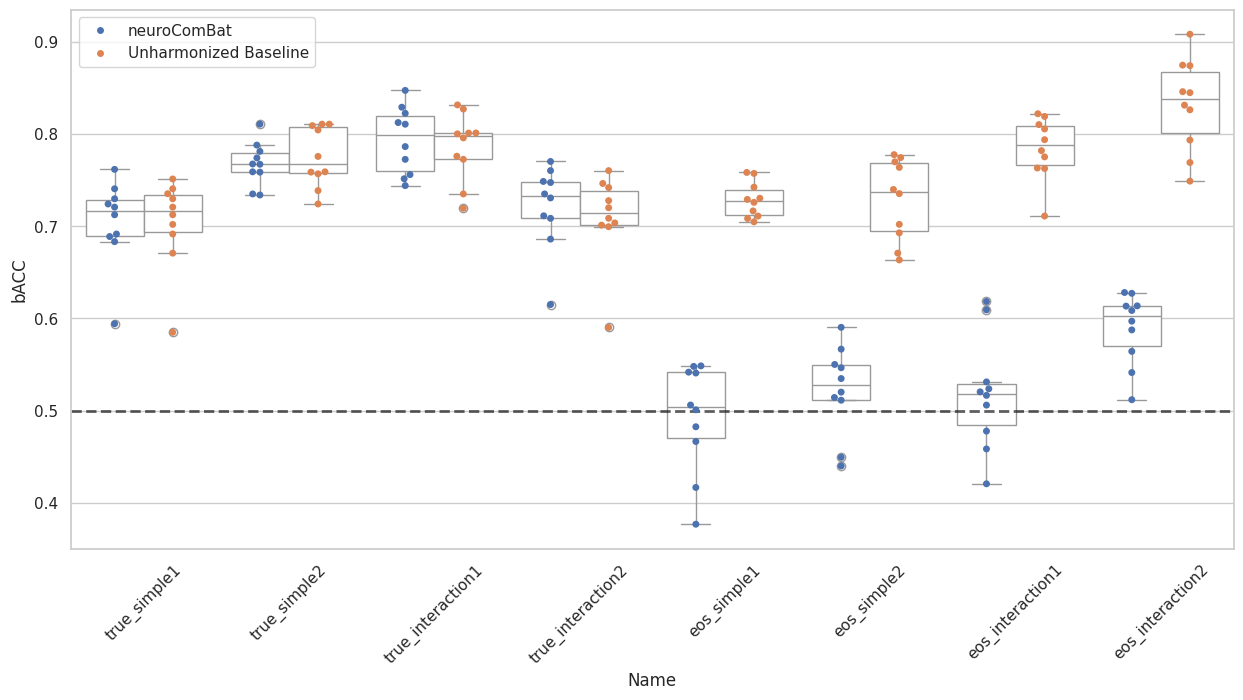

In [21]:
# %% Plotting resuts
fig, ax = plt.subplots(1, 1, figsize=[15, 7])

harm_methods = [
    "neuroComBat",
    "Unharmonized Baseline",
]

sns.swarmplot(data=results, x="Name", y="bACC", hue="Method", hue_order=harm_methods, dodge=True, ax=ax)

sns.boxplot(
    data=results,
    color="w",
    zorder=1,
    x="Name",
    y="bACC",
    hue="Method",
    hue_order=harm_methods,
    dodge=True,
    ax=ax,
    palette=["w"] * len(harm_methods),
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[: len(harm_methods)], labels[: len(harm_methods)])
ax.axhline(0.5, lw=2, color="k", ls="--", alpha=0.7, label="Chance level")
plt.grid(axis="y")
plt.grid(axis="y")
plt.xticks(rotation=45)

plt.show()
# %%

## 6) Take-home message
- The final markdown note states:
    - `neuroComBat` removes the `eos` site effect while preserving the `true` signal.
- The plot and results demonstrate the method’s ability to reduce spurious site-related variation and maintain true biological effect performance.